# Neural Network Function Fitting

Fitting a 1-D analytical function with a small neural network, end to end: build the dataset,
define the model, train it, and check what it learned.

The worked example fits

$$f(x) = x\sin(x) \qquad\text{on}\qquad x \in [-10, 10],$$

Most of the notebook is provided as scaffolding. A few key lines are intentionally replaced by
**TODOs** for you to implement before the notebook will run end to end. The homework is a
different function with different requirements, so you will be adapting this rather than simply
re-running it.

The code follows PyTorch's
**[Introduction to PyTorch](https://docs.pytorch.org/tutorials/beginner/introyt/)** series, so
the names and the shape of the training loop should look familiar if you have worked through it.

## Requirements

Everything this notebook needs, in one line. `pip install` leaves a package alone if a
compatible version is already there, so this is safe to re-run and will print "Requirement
already satisfied" on a machine that is already set up.

In [2]:
%pip install torch numpy matplotlib tensorboard

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [3]:
import os
import sys, time, random, platform
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

# PyTorch TensorBoard support, as in the introyt training tutorial
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG = []
def log(msg=""):
    LOG.append(str(msg)); print(msg)

if torch.cuda.is_available():
    DEVICE, BACKEND = torch.device("cuda"), "CUDA"
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE, BACKEND = torch.device("mps"), "MPS (Apple Silicon)"
else:
    DEVICE, BACKEND = torch.device("cpu"), "CPU"

SEED = 0
def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
seed_everything()

log(f"python      : {sys.version.split()[0]} on {platform.system()} {platform.machine()}")
log(f"torch       : {torch.__version__}   numpy: {np.__version__}   matplotlib: {matplotlib.__version__}")
log(f"backend     : {BACKEND}  ({DEVICE})")
if DEVICE.type == "cuda":
    log(f"gpu         : {torch.cuda.get_device_name(0)}  |  cuda {torch.version.cuda}")
log(f"seed        : {SEED}")

python      : 3.13.12 on Windows AMD64
torch       : 2.13.0+cpu   numpy: 2.4.3   matplotlib: 3.10.8
backend     : CPU  (cpu)
seed        : 0


## 1. Function definition and data generation

We build **one** dataset over the whole domain and split it three ways: a **training** set the
optimizer sees, a **validation** set for scoring during training, and a **test** set held back
for the final numbers and every plot.

> TIP: three splits, three jobs. The **training** set is the only one the optimizer sees; the
**validation** set picks the best epoch in section 4 and is what you would tune
hyperparameters against; the **test** set is scored once, at the end. Never make a choice
based on the test score — the moment you do, it stops measuring generalisation and becomes
just another validation set.

Training set has 1400 samples
Validation set has 300 samples
Test set has 300 samples


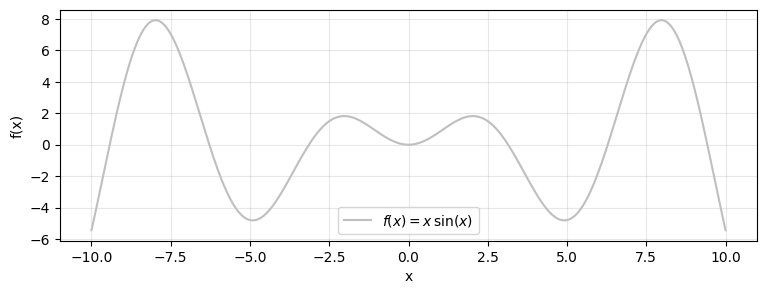

In [3]:
X_MIN, X_MAX = -10.0, 10.0
N_TOTAL = 2000
BATCH_SIZE = 140

# TODO 1: Define the target function f(x) = x * sin(x).
# Hint: use PyTorch operations so the function works directly on tensors.
def f(x):
    return x * torch.sin(x)

# TODO 2: Create N_TOTAL evenly spaced x values on [X_MIN, X_MAX].
# The network expects shape [N, 1], so add a singleton second dimension.
x_all = torch.linspace(X_MIN, X_MAX, N_TOTAL, device=DEVICE).unsqueeze(1)

# TODO 3: Evaluate the target function at every x value.
y_all = f(x_all)

N_TRAIN = int(0.70 * N_TOTAL)
N_VAL   = int(0.15 * N_TOTAL)
N_TEST  = N_TOTAL - N_TRAIN - N_VAL

# Random permutation
g = torch.Generator().manual_seed(SEED)
indices = torch.randperm(N_TOTAL, generator=g)

train_idx = indices[:N_TRAIN]
val_idx   = indices[N_TRAIN:N_TRAIN + N_VAL]
test_idx  = indices[N_TRAIN + N_VAL:]

# Get tensors
x_train, y_train = x_all[train_idx], y_all[train_idx]
x_val,   y_val   = x_all[val_idx],   y_all[val_idx]
x_test,  y_test  = x_all[test_idx],  y_all[test_idx]

# Construct the datasets
training_set = torch.utils.data.TensorDataset(x_train, y_train)
validation_set = torch.utils.data.TensorDataset(x_val, y_val)
test_set = torch.utils.data.TensorDataset(x_test, y_test)

training_loader = torch.utils.data.DataLoader(
    training_set, batch_size=BATCH_SIZE, shuffle=True
)
validation_loader = torch.utils.data.DataLoader(
    validation_set, batch_size=BATCH_SIZE, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False
)

# Report
log(f"Training set has {len(training_set)} samples")
log(f"Validation set has {len(validation_set)} samples")
log(f"Test set has {len(test_set)} samples")

plt.figure(figsize=(9, 3))
plt.plot(x_all.cpu(), y_all.cpu(), lw=1.5, color="0.75", label="$f(x) = x\\,\\sin(x)$")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(alpha=0.3)
plt.legend()
plt.show()


## 2. Model definition

PyTorch models inherit from
[`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html): an
`__init__()` that defines the layers, and a `forward()` where the computation happens. This is
the `TinyModel` pattern from
**[Building Models with PyTorch](https://docs.pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html)**,
with the layer sizes changed for a 1-D regression and the activation swapped.

A [`Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer is one where
every input influences every output to a degree set by the layer's weights. Without a
non-linearity between them, a stack of `Linear` layers collapses into a single linear map and
cannot bend to fit a curve at all — inserting non-linear activations is what lets the model
simulate any function rather than just linear ones.


In [4]:
class FunctionFitter(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.linear1 = torch.nn.Linear(1, 64)
        self.activation = torch.nn.ReLU()
        self.linear2 = torch.nn.Linear(64, 64)
        self.linear3 = torch.nn.Linear(64, 1)

    def forward(self, x):
        # TODO 4: Implement the forward pass.
        # Apply linear1 -> activation -> linear2 -> activation -> linear3.
        # YOUR CODE HERE
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)

        return x

seed_everything()
model = FunctionFitter().to(DEVICE)

log(f"model: {sum(p.numel() for p in model.parameters()):,} parameters, "
    f"{sum(isinstance(m, torch.nn.Linear) for m in model.modules())} Linear layers")
print(model)


model: 4,353 parameters, 3 Linear layers
FunctionFitter(
  (linear1): Linear(in_features=1, out_features=64, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=64, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=1, bias=True)
)


### Check your understanding

**Q1.** Why do we need a nonlinear activation such as `ReLU` between the `Linear` layers? What would happen if every layer were only linear?

*Answer in 1–2 sentences.*

If the activation function were linear, it would be unable to approximate nonlinear functions as the layers are made up of linear transformations

## 3. Training loop

This is `train_one_epoch` from
**[Training with PyTorch](https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html)**. It enumerates data from the `DataLoader` and, on each pass:
gets a batch, zeros the gradients, runs an inference, computes the loss against the ground truth,
computes the backward gradients, and tells the optimizer to take one step. It reports the loss
every `REPORT_EVERY` batches and returns the average per-batch loss for the last such block.
> **Student task:** The five basic optimization operations in the loop below are intentionally incomplete. Fill them in using the surrounding comments and the PyTorch tutorial pattern.


In [5]:
EPOCHS, LR, REPORT_EVERY = 2000, 2e-3, len(training_loader)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # TODO 5: Clear gradients from the previous batch.
        optimizer.zero_grad()

        # TODO 6: Run the model on this batch.
        outputs = model(inputs)

        # TODO 7: Compute mean-squared error between predictions and labels.
        loss = loss_fn(outputs, labels)

        # TODO 8: Backpropagate the loss, then update the model weights.
        loss.backward()
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % REPORT_EVERY == REPORT_EVERY - 1:
            last_loss = running_loss / REPORT_EVERY
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss


### Check your understanding

**Q2.** Why do we call `optimizer.zero_grad()` before processing each batch?

**Q3.** What different jobs are performed by `loss.backward()` and `optimizer.step()`?

*Answer each question in 1–2 sentences.*

Pytorch accumulates gradients, so if you try to backpropogate before clearing it will add the new gradient to the previous. 

loss backward calculates the gradient with respect to the weights. optimizer.step() uses this calculated gradient to find the new weights

## 4. Run the training and output logs

The per-epoch loop, again based on the introyt tutorial. Each epoch does two things:

1. **Train.** The model is put in training mode and `train_one_epoch` runs one pass over the training batches.
2. **Validate.** The model is switched to evaluation mode and the validation split is scored inside
   [`torch.no_grad()`](https://pytorch.org/docs/stable/generated/torch.no_grad.html).

[`eval()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.eval.html) changes the behaviour of layers like dropout and batch normalization. This network has neither, but using the correct mode is an important PyTorch habit. `no_grad()` skips building a computation graph because validation does not update the weights.

Whenever the validation loss improves, the current model weights are saved to disk. The final epoch is not automatically the best one, so the test section later reloads this checkpoint.

> **Student task:** A few important lines in the training/validation workflow below are intentionally incomplete. Use the comments to put the model in the correct mode, evaluate the validation batch, compute its loss, and save the best weights.


In [6]:
# Initializing in a separate cell so we can easily add more epochs to the same run.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
writer = SummaryWriter(f"runs/lab01_trainer_{timestamp}")
epoch_number = 0

log("")
log(f"training: Adam(lr={LR}), cosine annealing, batch size {BATCH_SIZE}, {EPOCHS} epochs")

loss_history, vloss_history = [], []
best_vloss = 1_000_000.0
MODEL_PATH = "model_best.pt"

t0 = time.time()
for epoch in range(EPOCHS):
    # Training mode is the correct state while model parameters are being optimized.
    model.train()

    # Run one complete pass over the training set.
    avg_loss = train_one_epoch(epoch_number, writer)
    scheduler.step()

    running_vloss = 0.0

    # Evaluation mode should be used for validation/inference.
    model.eval()

    # During validation we only need predictions and losses; no gradients are needed.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata

            # Forward pass on validation data.
            voutputs = model(vinputs)

            # Validation MSE.
            vloss = loss_fn(voutputs, vlabels)

            running_vloss += vloss

    avg_vloss = (running_vloss / (i + 1)).item()

    loss_history.append(avg_loss)
    vloss_history.append(avg_vloss)

    if epoch_number % 200 == 0 or epoch_number == EPOCHS - 1:
        log(
            f"EPOCH {epoch_number + 1:>5d}:  "
            f"LOSS train {avg_loss:.4e} valid {avg_vloss:.4e}   "
            f"lr {scheduler.get_last_lr()[0]:.1e}   "
            f"{time.time() - t0:5.1f}s"
        )

    # Log the running loss averaged per batch, for both training and validation.
    writer.add_scalars(
        "Training vs. Validation Loss",
        {"Training": avg_loss, "Validation": avg_vloss},
        epoch_number + 1
    )

    # If validation improves, remember the score and save these model weights.
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        torch.save(model.state_dict(), MODEL_PATH)

    epoch_number += 1

writer.flush()
writer.close()

loss_history = np.asarray(loss_history)
vloss_history = np.asarray(vloss_history)
train_seconds = time.time() - t0

log("")
log(f"finished in {train_seconds:.1f}s on {BACKEND}")
log(
    f"final MSE {loss_history[-1]:.4e}   "
    f"(down {loss_history[0] / loss_history[-1]:.1e}x from the first epoch)"
)
log(f"best validation MSE {best_vloss:.4e}   (weights saved to {MODEL_PATH})")



training: Adam(lr=0.002), cosine annealing, batch size 140, 2000 epochs
EPOCH     1:  LOSS train 1.3608e+01 valid 1.3556e+01   lr 2.0e-03     0.1s
EPOCH   201:  LOSS train 9.1315e+00 valid 1.2593e+01   lr 2.0e-03     3.7s
EPOCH   401:  LOSS train 1.6075e+00 valid 3.0511e+00   lr 1.8e-03     7.3s
EPOCH   601:  LOSS train 1.1378e-02 valid 2.1245e-02   lr 1.6e-03    11.1s
EPOCH   801:  LOSS train 3.8997e-03 valid 1.9074e-03   lr 1.3e-03    14.7s
EPOCH  1001:  LOSS train 3.0166e-03 valid 2.6449e-03   lr 1.0e-03    18.6s
EPOCH  1201:  LOSS train 2.6680e-03 valid 1.0971e-03   lr 6.9e-04    24.9s
EPOCH  1401:  LOSS train 1.6566e-03 valid 9.7994e-04   lr 4.1e-04    30.3s
EPOCH  1601:  LOSS train 1.4055e-03 valid 8.0630e-04   lr 1.9e-04    34.9s
EPOCH  1801:  LOSS train 1.1936e-03 valid 6.7607e-04   lr 4.9e-05    39.4s
EPOCH  2000:  LOSS train 1.1492e-03 valid 6.4714e-04   lr 1.0e-07    44.1s

finished in 44.1s on CPU
final MSE 1.1492e-03   (down 1.2e+04x from the first epoch)
best validation 

In [6]:
def error_norms(pred, ref):
    p, r = pred.double(), ref.double()
    mse = F.mse_loss(p, r)                              # mean of the squared error
    return {"mse":    mse.item()}


# Score on the held-out test split, using the BEST weights rather than the last ones.
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

e_fn = error_norms(y_pred, y_test)
log("")
log(f"test mse {e_fn['mse']:>13.4e}")

with open("execution_log.txt", "w", encoding="utf-8") as fh:
    fh.write("\n".join(LOG) + "\n")
print("\nwrote execution_log.txt")


test mse    1.9075e-03

wrote execution_log.txt


## 5. Autograd verification

The trained network approximates $f(x)=x\sin(x)$. We can also ask PyTorch for the
derivative of the **network output with respect to its input**. This is different from
`loss.backward()`, which is used during training to compute gradients with respect to the
model parameters.

For the worked example,

$$
f(x)=x\sin(x), \qquad
\frac{df}{dx}=\sin(x)+x\cos(x).
$$

The cell below computes $d\hat{y}/dx$ using `torch.autograd.grad()` and compares it with
the exact analytical derivative using the $L_2$ norm.


In [8]:
# Use the best trained model and switch to evaluation mode.
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

# Make a fresh copy of the held-out test coordinates and tell PyTorch
# to track operations on x so that derivatives with respect to x can be computed.
x_grad = x_test.detach().clone().requires_grad_(True)

# Forward pass through the trained neural network.
y_grad_pred = model(x_grad)

# Compute d(network output) / dx using PyTorch autograd.
# grad_outputs supplies a vector of ones because y_grad_pred contains
# one output value for every test coordinate.
dy_dx_autograd = torch.autograd.grad(
    outputs=y_grad_pred,
    inputs=x_grad,
    grad_outputs=torch.ones_like(y_grad_pred),
    create_graph=False
)[0]

# Exact analytical derivative for f(x) = x * sin(x):
# df/dx = sin(x) + x*cos(x)
dy_dx_exact = torch.sin(x_grad) + x_grad * torch.cos(x_grad)

# L2 error between the autograd-computed network derivative
# and the exact analytical derivative.
derivative_l2 = torch.linalg.vector_norm(
    (dy_dx_autograd - dy_dx_exact).double()
).item()

# Relative L2 error is also useful because it normalizes the error
# by the magnitude of the exact derivative.
derivative_relative_l2 = derivative_l2 / torch.linalg.vector_norm(
    dy_dx_exact.double()
).item()

log("")
log(f"derivative L2 error          {derivative_l2:>13.4e}")
log(f"derivative relative L2 error {derivative_relative_l2:>13.4e}")

# Save the complete execution log after both function and derivative evaluation.
with open("execution_log.txt", "w", encoding="utf-8") as fh:
    fh.write("\n".join(LOG) + "\n")
print("\nwrote execution_log.txt")



derivative L2 error             9.6199e+00
derivative relative L2 error    1.2077e-01

wrote execution_log.txt


---

# HOMEWORK

Repeat the above for **your own target function**, and upload three files to Canvas, all as PDF.

The worked example is not a valid submission: it uses $x\sin(x)$ and only two hidden layers,
and it does not normalize its data. You need to change the target function, deepen the network,
and derive the new derivative yourself.

### Target function

Instantiate a feedforward network to approximate **one** of these, choosing the scalar
constants yourself so that the function shows enough oscillation and decay across your domain
$x \in [x_{\min}, x_{\max}]$:

$$f(x) = e^{-\alpha x}\sin(\omega x) \qquad
f(x) = \tanh(\beta x)\cos(\gamma x) \qquad
f(x) = A e^{-\frac{(x-\mu)^2}{2\sigma^2}} + cx^{2}$$


Training set has 1400 samples
Validation set has 300 samples
Test set has 300 samples
alpha is 0.1
omega is 1


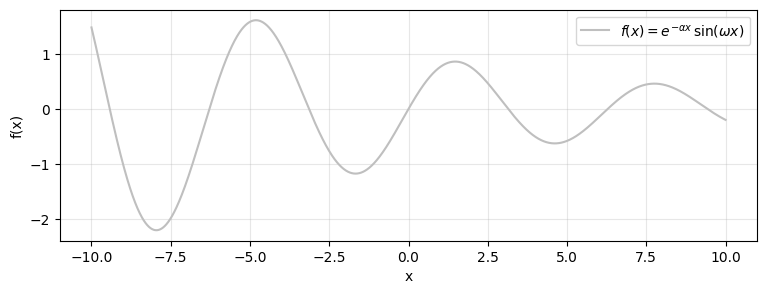

In [4]:
X_MIN, X_MAX = -10.0, 10.0
N_TOTAL = 2000
BATCH_SIZE = 140
alpha = 0.1
omega = 1

# TODO 1: Define the target function f(x) = x * sin(x).
# Hint: use PyTorch operations so the function works directly on tensors.
def f(x):
    return torch.exp(-alpha * x)*torch.sin(omega*x)

# TODO 2: Create N_TOTAL evenly spaced x values on [X_MIN, X_MAX].
# The network expects shape [N, 1], so add a singleton second dimension.
x_all = torch.linspace(X_MIN, X_MAX, N_TOTAL, device=DEVICE).unsqueeze(1)

# TODO 3: Evaluate the target function at every x value.
y_all = f(x_all)

N_TRAIN = int(0.70 * N_TOTAL)
N_VAL   = int(0.15 * N_TOTAL)
N_TEST  = N_TOTAL - N_TRAIN - N_VAL

# Random permutation
g = torch.Generator().manual_seed(SEED)
indices = torch.randperm(N_TOTAL, generator=g)

train_idx = indices[:N_TRAIN]
val_idx   = indices[N_TRAIN:N_TRAIN + N_VAL]
test_idx  = indices[N_TRAIN + N_VAL:]

# Get tensors
x_train, y_train = x_all[train_idx], y_all[train_idx]
x_val,   y_val   = x_all[val_idx],   y_all[val_idx]
x_test,  y_test  = x_all[test_idx],  y_all[test_idx]

# Construct the datasets
training_set = torch.utils.data.TensorDataset(x_train, y_train)
validation_set = torch.utils.data.TensorDataset(x_val, y_val)
test_set = torch.utils.data.TensorDataset(x_test, y_test)

training_loader = torch.utils.data.DataLoader(
    training_set, batch_size=BATCH_SIZE, shuffle=True
)
validation_loader = torch.utils.data.DataLoader(
    validation_set, batch_size=BATCH_SIZE, shuffle=False
)
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=BATCH_SIZE, shuffle=False
)

# Report
log(f"Training set has {len(training_set)} samples")
log(f"Validation set has {len(validation_set)} samples")
log(f"Test set has {len(test_set)} samples")
log(f"alpha is {alpha}")
log(f'omega is {omega}')
plt.figure(figsize=(9, 3))
plt.plot(x_all.cpu(), y_all.cpu(), lw=1.5, color="0.75", label="$f(x) = e^{- \\alpha x}\\,\\sin(\\omega x)$")
plt.xlabel("x"); plt.ylabel("f(x)"); plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [5]:
class FunctionFitter(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.linear1 = torch.nn.Linear(1, 64)
        self.activation = torch.nn.ReLU()
        self.linear2 = torch.nn.Linear(64, 64)
        self.linear3 = torch.nn.Linear(64, 1)

    def forward(self, x):
        # TODO 4: Implement the forward pass.
        # Apply linear1 -> activation -> linear2 -> activation -> linear3.
        # YOUR CODE HERE
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear2(x)
        x = self.activation(x)
        x = self.linear3(x)

        return x

seed_everything()
model = FunctionFitter().to(DEVICE)

log(f"model: {sum(p.numel() for p in model.parameters()):,} parameters, "
    f"{sum(isinstance(m, torch.nn.Linear) for m in model.modules())} Linear layers")
print(model)


model: 4,353 parameters, 3 Linear layers
FunctionFitter(
  (linear1): Linear(in_features=1, out_features=64, bias=True)
  (activation): ReLU()
  (linear2): Linear(in_features=64, out_features=64, bias=True)
  (linear3): Linear(in_features=64, out_features=1, bias=True)
)


In [6]:
EPOCHS, LR, REPORT_EVERY = 2000, 2e-3, len(training_loader)

loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(training_loader):
        # Every data instance is an input + label pair
        inputs, labels = data

        # TODO 5: Clear gradients from the previous batch.
        optimizer.zero_grad()

        # TODO 6: Run the model on this batch.
        outputs = model(inputs)

        # TODO 7: Compute mean-squared error between predictions and labels.
        loss = loss_fn(outputs, labels)

        # TODO 8: Backpropagate the loss, then update the model weights.
        loss.backward()
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % REPORT_EVERY == REPORT_EVERY - 1:
            last_loss = running_loss / REPORT_EVERY
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.

    return last_loss


In [7]:
# Initializing in a separate cell so we can easily add more epochs to the same run.
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
writer = SummaryWriter(f"runs/lab01_trainer_{timestamp}")
epoch_number = 0

log("")
log(f"training: Adam(lr={LR}), cosine annealing, batch size {BATCH_SIZE}, {EPOCHS} epochs")

loss_history, vloss_history = [], []
best_vloss = 1_000_000.0
MODEL_PATH = "model_best.pt"

t0 = time.time()
for epoch in range(EPOCHS):
    # Training mode is the correct state while model parameters are being optimized.
    model.train()

    # Run one complete pass over the training set.
    avg_loss = train_one_epoch(epoch_number, writer)
    scheduler.step()

    running_vloss = 0.0

    # Evaluation mode should be used for validation/inference.
    model.eval()

    # During validation we only need predictions and losses; no gradients are needed.
    with torch.no_grad():
        for i, vdata in enumerate(validation_loader):
            vinputs, vlabels = vdata

            # Forward pass on validation data.
            voutputs = model(vinputs)

            # Validation MSE.
            vloss = loss_fn(voutputs, vlabels)

            running_vloss += vloss

    avg_vloss = (running_vloss / (i + 1)).item()

    loss_history.append(avg_loss)
    vloss_history.append(avg_vloss)

    if epoch_number % 200 == 0 or epoch_number == EPOCHS - 1:
        log(
            f"EPOCH {epoch_number + 1:>5d}:  "
            f"LOSS train {avg_loss:.4e} valid {avg_vloss:.4e}   "
            f"lr {scheduler.get_last_lr()[0]:.1e}   "
            f"{time.time() - t0:5.1f}s"
        )

    # Log the running loss averaged per batch, for both training and validation.
    writer.add_scalars(
        "Training vs. Validation Loss",
        {"Training": avg_loss, "Validation": avg_vloss},
        epoch_number + 1
    )

    # If validation improves, remember the score and save these model weights.
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        torch.save(model.state_dict(), MODEL_PATH)

    epoch_number += 1

writer.flush()
writer.close()

loss_history = np.asarray(loss_history)
vloss_history = np.asarray(vloss_history)
train_seconds = time.time() - t0

log("")
log(f"finished in {train_seconds:.1f}s on {BACKEND}")
log(
    f"final MSE {loss_history[-1]:.4e}   "
    f"(down {loss_history[0] / loss_history[-1]:.1e}x from the first epoch)"
)
log(f"best validation MSE {best_vloss:.4e}   (weights saved to {MODEL_PATH})")



training: Adam(lr=0.002), cosine annealing, batch size 140, 2000 epochs
EPOCH     1:  LOSS train 7.6404e-01 valid 8.5070e-01   lr 2.0e-03     0.0s
EPOCH   201:  LOSS train 9.5637e-05 valid 6.5516e-05   lr 2.0e-03     6.2s
EPOCH   401:  LOSS train 4.0122e-03 valid 8.1863e-04   lr 1.8e-03    11.6s
EPOCH   601:  LOSS train 5.6911e-03 valid 1.1311e-03   lr 1.6e-03    17.2s
EPOCH   801:  LOSS train 1.1803e-04 valid 6.2159e-05   lr 1.3e-03    22.7s
EPOCH  1001:  LOSS train 8.4910e-05 valid 2.7833e-05   lr 1.0e-03    28.3s
EPOCH  1201:  LOSS train 5.8358e-05 valid 5.0959e-05   lr 6.9e-04    33.7s
EPOCH  1401:  LOSS train 4.8770e-05 valid 1.8962e-04   lr 4.1e-04    38.9s
EPOCH  1601:  LOSS train 1.2372e-05 valid 5.8839e-06   lr 1.9e-04    44.3s
EPOCH  1801:  LOSS train 7.7949e-06 valid 4.4264e-06   lr 4.9e-05    49.5s
EPOCH  2000:  LOSS train 6.6936e-06 valid 4.1915e-06   lr 1.0e-07    54.7s

finished in 54.7s on CPU
final MSE 6.6936e-06   (down 1.1e+05x from the first epoch)
best validation 

In [8]:
def error_norms(pred, ref):
    p, r = pred.double(), ref.double()
    mse = F.mse_loss(p, r)                              # mean of the squared error
    return {"mse":    mse.item()}


# Score on the held-out test split, using the BEST weights rather than the last ones.
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()
with torch.no_grad():
    y_pred = model(x_test)

e_fn = error_norms(y_pred, y_test)
log("")
log(f"test mse {e_fn['mse']:>13.4e}")

with open("execution_log.txt", "w", encoding="utf-8") as fh:
    fh.write("\n".join(LOG) + "\n")
print("\nwrote execution_log.txt")


test mse    8.7829e-06

wrote execution_log.txt



derivative L2 error             1.6757e+00
derivative relative L2 error    9.1841e-02

wrote execution_log.txt


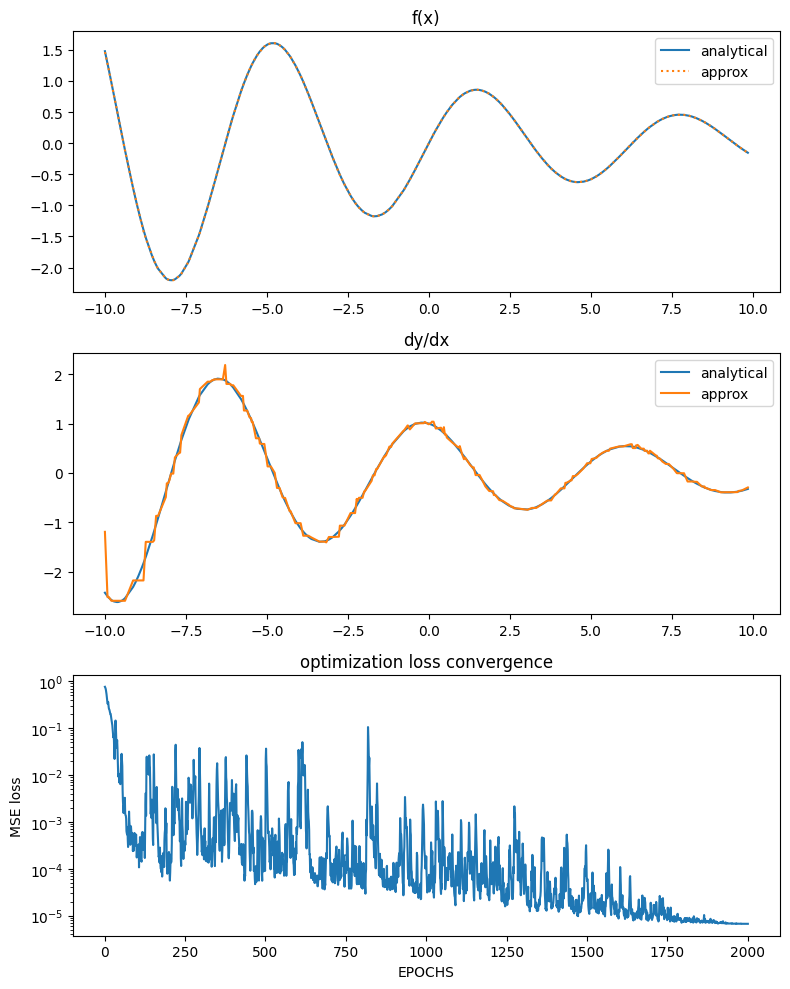

In [9]:
# Use the best trained model and switch to evaluation mode.
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

# Make a fresh copy of the held-out test coordinates and tell PyTorch
# to track operations on x so that derivatives with respect to x can be computed.
x_grad = x_test.detach().clone().requires_grad_(True)

# Forward pass through the trained neural network.
y_grad_pred = model(x_grad)

# Compute d(network output) / dx using PyTorch autograd.
# grad_outputs supplies a vector of ones because y_grad_pred contains
# one output value for every test coordinate.
dy_dx_autograd = torch.autograd.grad(
    outputs=y_grad_pred,
    inputs=x_grad,
    grad_outputs=torch.ones_like(y_grad_pred),
    create_graph=False
)[0]

dy_dx_exact = torch.exp(-alpha*x_grad) * (-alpha*torch.sin(omega*x_grad) + omega*torch.cos(omega*x_grad))

# L2 error between the autograd-computed network derivative
# and the exact analytical derivative.
derivative_l2 = torch.linalg.vector_norm(
    (dy_dx_autograd - dy_dx_exact).double()
).item()

# Relative L2 error is also useful because it normalizes the error
# by the magnitude of the exact derivative.
derivative_relative_l2 = derivative_l2 / torch.linalg.vector_norm(
    dy_dx_exact.double()
).item()

log("")
log(f"derivative L2 error          {derivative_l2:>13.4e}")
log(f"derivative relative L2 error {derivative_relative_l2:>13.4e}")

# Save the complete execution log after both function and derivative evaluation.
with open("execution_log.txt", "w", encoding="utf-8") as fh:
    fh.write("\n".join(LOG) + "\n")
print("\nwrote execution_log.txt")

def fprime(x):
    return np.exp(-alpha*x) * (-alpha*np.sin(omega*x) + omega*np.cos(omega*x))
idx = torch.argsort(x_test.squeeze())

x_sorted = x_test.squeeze()[idx]
y_sorted = y_test.squeeze()[idx]
x_grad_sorted = x_grad.squeeze()[idx]
dy_dx_autograd_sorted = dy_dx_autograd.squeeze()[idx]
fig,ax = plt.subplots(3,1,figsize = (8,10))
ax[0].plot(x_sorted.unsqueeze(1),f(x_sorted.unsqueeze(1)),label = 'analytical')
ax[0].plot(x_sorted.unsqueeze(1),model(x_sorted.unsqueeze(1)).detach().numpy(),ls = 'dotted', label = 'approx')
ax[0].legend()
ax[0].set_title( 'f(x)')
x = x_sorted.detach().numpy()
ax[1].plot(x,fprime(x),label = 'analytical')
ax[1].plot(x_grad_sorted.unsqueeze(1).detach().numpy(),dy_dx_autograd_sorted.unsqueeze(1).detach().numpy(),label = 'approx')
ax[1].set_title('dy/dx')
ax[1].legend()
ax[2].plot(np.arange(EPOCHS)+1,loss_history)
ax[2].set_xlabel('EPOCHS')
ax[2].set_ylabel('MSE loss')
ax[2].set_yscale('log')
ax[2].set_title('optimization loss convergence')
plt.tight_layout()
plt.savefig("results.pdf", bbox_inches="tight")
plt.show()


In [89]:
print(len(loss_history))

2000


In [13]:
plt.tight_layout()
plt.savefig("results.pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>